In [2]:
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv("insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1338, 7)

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df_clean = df.copy()

In [11]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df_clean = df_clean.drop_duplicates()

In [14]:
df_clean.duplicated().sum()

np.int64(0)

In [15]:
df_clean.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [16]:
print(df_clean["sex"].unique())
print(df_clean["smoker"].unique())
print(df_clean["region"].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [17]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["sex", "smoker", "region"],
    dtype=int
)

In [18]:
df_clean.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [19]:
print("Before preprocessing:")
print(df.columns.tolist())

print("\nAfter preprocessing:")
print(df_clean.columns.tolist())

Before preprocessing:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

After preprocessing:
['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_female        1337 non-null   int64  
 5   sex_male          1337 non-null   int64  
 6   smoker_no         1337 non-null   int64  
 7   smoker_yes        1337 non-null   int64  
 8   region_northeast  1337 non-null   int64  
 9   region_northwest  1337 non-null   int64  
 10  region_southeast  1337 non-null   int64  
 11  region_southwest  1337 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 135.8 KB


In [21]:
df_clean.isnull().sum()

,0
age,0
bmi,0
children,0
charges,0
sex_female,0
sex_male,0
smoker_no,0
smoker_yes,0
region_northeast,0
region_northwest,0


In [22]:
df_clean.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


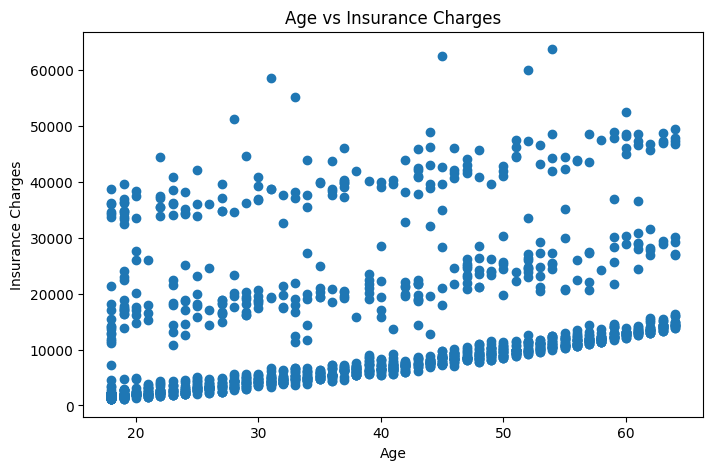

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_clean["age"], df_clean["charges"])
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.show()

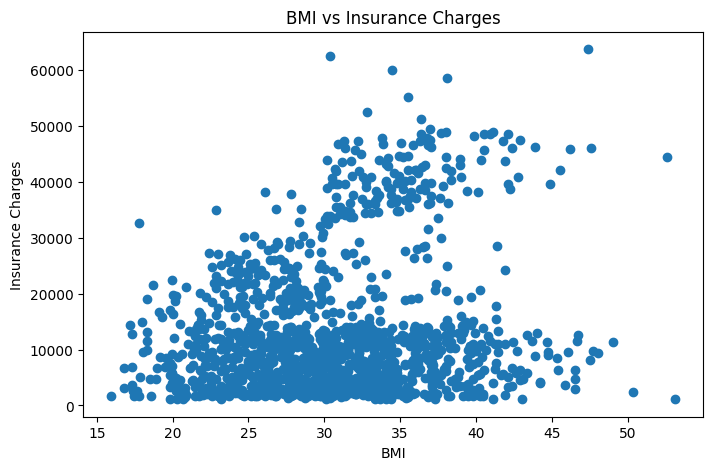

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["bmi"], df_clean["charges"])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

/tmp/ipykernel_2800/2379411273.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


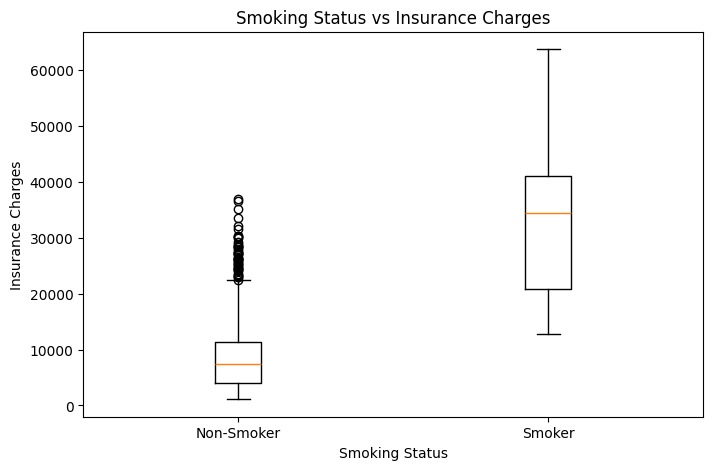

In [25]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [
        df_clean[df_clean["smoker_yes"] == 0]["charges"],
        df_clean[df_clean["smoker_yes"] == 1]["charges"]
    ],
    labels=["Non-Smoker", "Smoker"]
)
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")
plt.title("Smoking Status vs Insurance Charges")
plt.show()

In [26]:
correlation = df_clean.corr(numeric_only=True)["charges"].sort_values(ascending=False)

correlation

,charges
charges,1.000000
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_northeast,0.005945
region_northwest,-0.038695
region_southwest,-0.043637


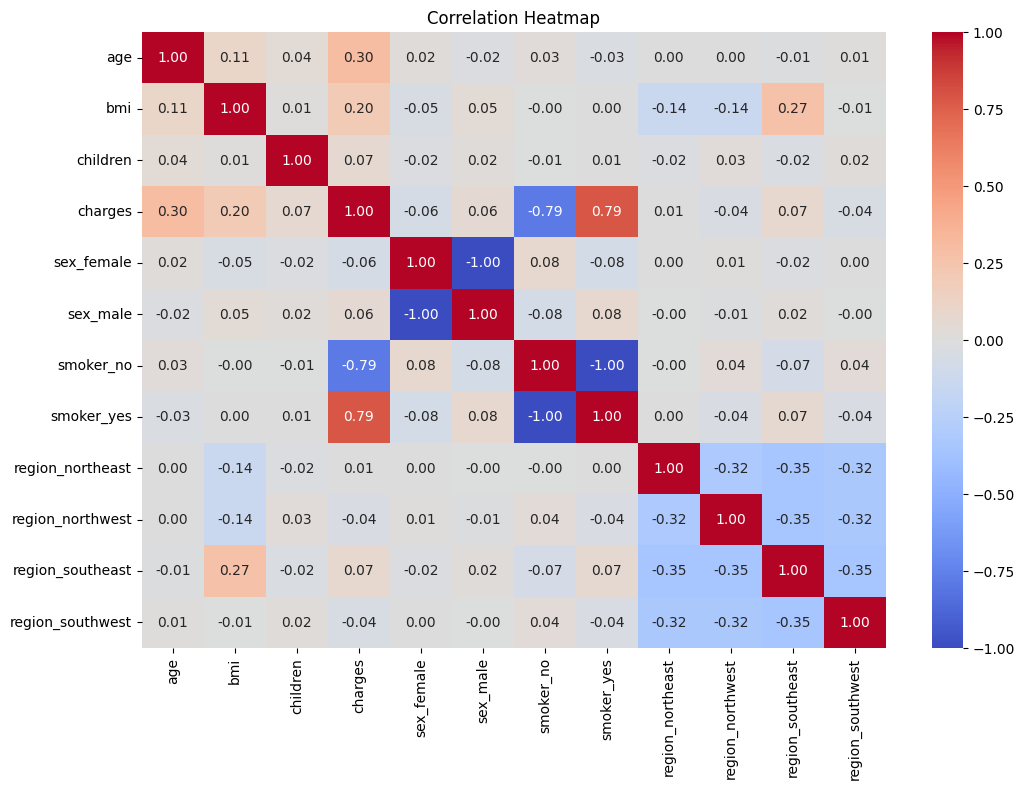

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Important Observations**

Age: Insurance charges generally show an increasing trend with age.

BMI: BMI has some relationship with insurance charges, but the data points are relatively scattered.

Smoking Status: Smokers generally have considerably higher insurance charges than non-smokers.

Correlation: bold textCorrelation analysis helps identify which features have stronger relationships with the target variable charges.

Important Features: Based on the visualizations and correlation analysis, features such as smoking status and age appear particularly useful for predicting insurance charges.

# Phase 5 — Select and Train the Machine Learning Model

In [28]:
X = df_clean.drop("charges", axis=1)
y = df_clean["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 11)
y shape: (1337,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1069, 11)
X_test: (268, 11)
y_train: (1069,)
y_test: (268,)


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
y_pred = model.predict(X_test)

print("Sample predictions:")
print(y_pred[:5])

Sample predictions:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


In [33]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values[:5],
    "Predicted Charges": y_pred[:5]
})

comparison

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657


# Phase 6 — Evaluate the Machine Learning Model

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [35]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4177.045561036319


In [36]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 35478020.67523559


In [37]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 5956.342894363587


In [38]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8069287081198012


In [39]:
print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 4177.045561036319
MSE : 35478020.67523559
RMSE: 5956.342894363587
R²  : 0.8069287081198012


In [40]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values[:10],
    "Predicted Charges": y_pred[:10]
})

comparison

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [41]:
# ============================================================
# PHASE 7 - BUILD PREDICTION APPLICATION
# ============================================================

print("Phase 7: Medical Insurance Cost Prediction Application")

Phase 7: Medical Insurance Cost Prediction Application


In [42]:
import pandas as pd
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [43]:
print("Dataset shape:", df.shape)
print("Dataset columns:")
print(df.columns.tolist())

Dataset shape: (1338, 7)
Dataset columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [44]:
# Features and target
X = df.drop("charges", axis=1)
y = df["charges"]

# Numerical and categorical features
numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Complete ML pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [45]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [46]:
# Test prediction using one existing test record
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]

print("Sample predicted insurance cost:")
print(f"${prediction:,.2f}")

Sample predicted insurance cost:
$8,969.55


In [47]:
def predict_insurance_cost(
    age,
    bmi,
    children,
    gender,
    smoker,
    region
):

    # Create input in the same format as original dataset
    input_data = pd.DataFrame({
        "age": [age],
        "sex": [gender],
        "bmi": [bmi],
        "children": [children],
        "smoker": [smoker],
        "region": [region]
    })

    # Predict
    prediction = model.predict(input_data)[0]

    # Return formatted result
    return f"${prediction:,.2f}"

In [48]:
test_result = predict_insurance_cost(
    25,
    23.5,
    0,
    "Female",
    "No",
    "Southeast"
)

print("Prediction:", test_result)

Prediction: $2,414.85


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [50]:
# ============================================================
# PHASE 7
# MEDICAL INSURANCE COST PREDICTION APPLICATION
# COMPLETE FINAL VERSION
# ============================================================

import os
import pandas as pd
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_PATH = "/content/insurance.csv"

if not os.path.exists(DATA_PATH):

    raise FileNotFoundError(
        "insurance.csv not found in /content. "
        "Please upload insurance.csv to Colab first."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ============================================================
# 2. SELECT FEATURES AND TARGET
# ============================================================

X = df[
    [
        "age",
        "sex",
        "bmi",
        "children",
        "smoker",
        "region"
    ]
]

y = df["charges"]


# ============================================================
# 3. DEFINE FEATURES
# ============================================================

numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]


# ============================================================
# 4. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]
)


# ============================================================
# 5. MACHINE LEARNING PIPELINE
# ============================================================

model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "regressor",
            LinearRegression()
        )

    ]
)


# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")


# ============================================================
# 8. CHECK MODEL
# ============================================================

test_prediction = model.predict(
    X_test.iloc[[0]]
)[0]

print(
    "Test prediction:",
    f"${test_prediction:,.2f}"
)


# ============================================================
# 9. PREDICTION FUNCTION
# ============================================================

def predict_insurance_cost(
    age,
    bmi,
    children,
    gender,
    smoker,
    region
):

    try:

        # Validate inputs

        if age is None or bmi is None or children is None:
            return """
            <div class="cost-display error-box">
                <div class="cost-label">
                    PLEASE ENTER ALL DETAILS
                </div>
            </div>
            """


        # Create DataFrame using ORIGINAL dataset columns

        input_data = pd.DataFrame({

            "age": [
                float(age)
            ],

            "sex": [
                str(gender)
            ],

            "bmi": [
                float(bmi)
            ],

            "children": [
                int(children)
            ],

            "smoker": [
                str(smoker)
            ],

            "region": [
                str(region)
            ]

        })


        # Predict

        prediction = model.predict(
            input_data
        )[0]


        # Make sure prediction is not negative

        prediction = max(
            0,
            prediction
        )


        # Return professional result card

        return f"""

        <div class="cost-display">

            <div class="cost-label">
                ESTIMATED INSURANCE COST
            </div>

            <div class="cost-value">
                ${prediction:,.2f}
            </div>

            <div class="cost-period">
                Estimated Annual Medical Insurance Cost
            </div>

        </div>

        """


    except Exception as e:

        return f"""

        <div class="cost-display error-box">

            <div class="cost-label">
                PREDICTION ERROR
            </div>

            <div class="error-message">
                {str(e)}
            </div>

        </div>

        """


# ============================================================
# 10. CUSTOM CSS
# ============================================================

css = """

/* ==========================================================
   GLOBAL
   ========================================================== */

body {

    margin: 0;

    background: #f5f9fc;

    font-family:
        Arial,
        Helvetica,
        sans-serif;

}

.gradio-container {

    max-width: 1180px !important;

    margin: auto !important;

    padding:
        0
        28px
        35px !important;

}


/* ==========================================================
   NAVBAR
   ========================================================== */

.navbar {

    height: 76px;

    background: white;

    display: flex;

    align-items: center;

    justify-content: space-between;

    padding:
        0
        28px;

    margin:
        0
        -28px;

    border-bottom:
        1px solid
        #e7eef3;

}

.brand {

    display: flex;

    align-items: center;

    gap: 12px;

}

.brand-icon {

    width: 45px;

    height: 45px;

    border-radius: 50%;

    background: #167d70;

    color: white;

    display: flex;

    align-items: center;

    justify-content: center;

    font-size: 23px;

}

.brand-name {

    color: #12466b;

    font-size: 21px;

    font-weight: 700;

}

.brand-subtitle {

    color: #8aa4b8;

    font-size: 11px;

    margin-top: 2px;

}

.nav-right {

    color: #53738c;

    font-size: 12px;

}


/* ==========================================================
   HERO
   ========================================================== */

.hero {

    background:
        linear-gradient(
            105deg,
            #f4fbfd,
            #e8f8fa
        );

    min-height: 220px;

    border-radius:
        0
        0
        20px
        20px;

    padding:
        25px
        38px;

    overflow: hidden;

}

.hero-text {

    padding-top: 18px;

}

.hero-badge {

    display: inline-block;

    background: #d7f7ef;

    color: #087f70;

    padding:
        7px
        14px;

    border-radius: 20px;

    font-size: 12px;

    font-weight: 700;

}

.hero-title {

    color: #12395b;

    font-size: 34px;

    font-weight: 700;

    line-height: 1.15;

    margin:
        13px
        0
        12px;

}

.hero-description {

    color: #426b8f;

    font-size: 14px;

    line-height: 1.7;

    max-width: 620px;

}


/* ==========================================================
   HERO IMAGE
   ========================================================== */

.hero-image {

    background: transparent !important;

    border: none !important;

    box-shadow: none !important;

}

.hero-image img {

    object-fit: contain !important;

    max-height: 220px !important;

}


/* ==========================================================
   SECTION HEADINGS
   ========================================================== */

.section-heading {

    color: #12395b;

    font-size: 19px;

    font-weight: 700;

    margin:
        24px
        0
        12px;

}


/* ==========================================================
   INPUT CARD
   ========================================================== */

.input-card {

    background: white;

    border:
        1px solid
        #e3ebf0;

    border-radius: 17px;

    padding: 24px !important;

    box-shadow:
        0
        7px
        25px
        rgba(
            25,
            65,
            90,
            0.06
        );

}


/* ==========================================================
   INPUT LABELS
   ========================================================== */

label span {

    color: #244b69 !important;

    font-size: 12px !important;

    font-weight: 700 !important;

}

input,
select {

    background: #fbfdff !important;

    border:
        1px solid
        #d9e5ec !important;

    border-radius: 9px !important;

    color: #244b69 !important;

}


/* ==========================================================
   BUTTON
   ========================================================== */

#predict-button {

    background: #159a8b !important;

    color: white !important;

    border: none !important;

    border-radius: 10px !important;

    height: 50px !important;

    font-size: 15px !important;

    font-weight: 700 !important;

    margin-top: 12px !important;

}

#predict-button:hover {

    background: #117d72 !important;

}


/* ==========================================================
   PREDICTION CARD
   ========================================================== */

.prediction-card {

    background: #104c69;

    border-radius: 17px;

    padding: 28px !important;

    min-height: 315px;

    box-shadow:
        0
        10px
        30px
        rgba(
            16,
            76,
            105,
            0.16
        );

}

.prediction-title {

    color: white;

    font-size: 20px;

    font-weight: 700;

}

.prediction-subtitle {

    color: #c5dce7;

    font-size: 12px;

    margin-top: 4px;

}


/* ==========================================================
   COST DISPLAY
   ========================================================== */

.cost-display {

    background: #199b91;

    border:
        2px solid
        #44c6b8;

    border-radius: 16px;

    min-height: 125px;

    margin-top: 28px;

    display: flex;

    flex-direction: column;

    align-items: center;

    justify-content: center;

    text-align: center;

    box-sizing: border-box;

    padding:
        15px
        20px;

}

.cost-label {

    color: white;

    font-size: 12px;

    font-weight: 700;

    letter-spacing: 0.5px;

    margin-bottom: 8px;

}

.cost-value {

    color: white;

    font-size: 32px;

    font-weight: 800;

    line-height: 1.2;

}

.cost-period {

    color: #d7f7f3;

    font-size: 10px;

    margin-top: 7px;

}

.error-box {

    background: #fff5f5;

    border:
        2px solid
        #e57373;

}

.error-box .cost-label {

    color: #b3261e;

}

.error-message {

    color: #b3261e;

    font-size: 12px;

    max-width: 100%;

    word-break: break-word;

}


/* ==========================================================
   MODEL NOTE
   ========================================================== */

.model-note {

    text-align: center;

    color: #c4dbe6;

    font-size: 12px;

    margin-top: 25px;

}


/* ==========================================================
   HOW IT WORKS
   ========================================================== */

.workflow-card {

    background: white;

    border:
        1px solid
        #e3ebf0;

    border-radius: 15px;

    padding: 20px;

    min-height: 125px;

}

.workflow-number {

    width: 27px;

    height: 27px;

    background: #e1f3f1;

    color: #087f70;

    border-radius: 50%;

    display: flex;

    align-items: center;

    justify-content: center;

    font-size: 11px;

    font-weight: 700;

}

.workflow-title {

    color: #163c5c;

    font-size: 14px;

    font-weight: 700;

    margin:
        9px
        0
        6px;

}

.workflow-text {

    color: #7290a5;

    font-size: 12px;

    line-height: 1.6;

}


/* ==========================================================
   MODEL INFORMATION
   ========================================================== */

.model-card {

    background: #e8f8f5;

    border-radius: 15px;

    padding: 20px;

    min-height: 125px;

}

.model-title {

    color: #087f70;

    font-size: 15px;

    font-weight: 700;

    margin-bottom: 13px;

}

.model-row {

    display: flex;

    margin-bottom: 8px;

    font-size: 12px;

}

.model-label {

    width: 70px;

    color: #32756f;

    font-weight: 700;

}

.model-value {

    color: #426b6a;

}


/* ==========================================================
   FOOTER
   ========================================================== */

.footer {

    text-align: center;

    color: #89a1b2;

    font-size: 11px;

    margin-top: 25px;

    line-height: 1.7;

}


/* ==========================================================
   MOBILE
   ========================================================== */

@media (max-width: 800px) {

    .navbar {

        padding:
            0
            15px;

    }

    .nav-right {

        display: none;

    }

    .hero-title {

        font-size: 27px;

    }

    .hero {

        padding:
            20px;

    }

}


/* ==========================================================
   REMOVE UNNECESSARY GRADIO BORDER
   ========================================================== */

footer {

    display: none !important;

}

"""


# ============================================================
# 11. BUILD GRADIO APPLICATION
# ============================================================

with gr.Blocks(
    title="Medical Insurance Cost Predictor"
) as app:


    # ========================================================
    # NAVBAR
    # ========================================================

    gr.HTML("""
    <div class="navbar">

        <div class="brand">

            <div class="brand-icon">
                ♥
            </div>

            <div>

                <div class="brand-name">
                    HealthPredict
                </div>

                <div class="brand-subtitle">
                    Smarter Healthcare Decisions
                </div>

            </div>

        </div>

        <div class="nav-right">
            🛡 Better Insights
            &nbsp; • &nbsp;
            Healthier Tomorrow
        </div>

    </div>
    """)


    # ========================================================
    # HERO
    # ========================================================

    with gr.Row(
        elem_classes="hero"
    ):

        with gr.Column(
            scale=6,
            elem_classes="hero-text"
        ):

            gr.HTML("""
            <div class="hero-badge">
                ✣ &nbsp; ML Powered
            </div>

            <h1 class="hero-title">
                Medical Insurance Cost Predictor
            </h1>

            <div class="hero-description">

                Estimate your medical insurance cost using a
                machine learning model trained on historical
                healthcare data. Get a quick estimate based
                on your personal information.

            </div>
            """)


        with gr.Column(
            scale=5
        ):

            image_path = (
                "/content/"
                "healthcare_hero_illustration.png"
            )

            if os.path.exists(image_path):

                gr.Image(

                    value=image_path,

                    show_label=False,

                    interactive=False,

                    container=False,

                    elem_classes="hero-image"

                )

            else:

                gr.HTML("""
                <div style="
                    height:210px;
                    display:flex;
                    align-items:center;
                    justify-content:center;
                    color:#7290a5;
                    font-size:12px;">
                    Healthcare illustration
                </div>
                """)


    # ========================================================
    # MAIN SECTION
    # ========================================================

    with gr.Row():


        # ====================================================
        # LEFT SIDE
        # ====================================================

        with gr.Column(
            scale=6
        ):

            gr.HTML("""
            <div class="section-heading">
                👤 Personal Information
            </div>
            """)


            with gr.Column(
                elem_classes="input-card"
            ):

                gr.HTML("""
                <div style="
                    color:#163c5c;
                    font-size:18px;
                    font-weight:700;">

                    Personal Information

                </div>

                <div style="
                    color:#7290a5;
                    font-size:12px;
                    margin:4px 0 18px;">

                    Please enter your details to estimate
                    the insurance cost.

                </div>
                """)


                # --------------------------------------------
                # AGE + BMI
                # --------------------------------------------

                with gr.Row():

                    age = gr.Number(

                        label="Age",

                        value=25,

                        minimum=1,

                        maximum=100

                    )

                    bmi = gr.Number(

                        label="BMI",

                        value=23.5,

                        minimum=10,

                        maximum=60

                    )


                # --------------------------------------------
                # CHILDREN + GENDER
                # --------------------------------------------

                with gr.Row():

                    children = gr.Number(

                        label="Number of Children",

                        value=0,

                        minimum=0,

                        maximum=10,

                        precision=0

                    )

                    gender = gr.Dropdown(

                        choices=[
                            "Female",
                            "Male"
                        ],

                        value="Female",

                        label="Gender"

                    )


                # --------------------------------------------
                # SMOKING + REGION
                # --------------------------------------------

                with gr.Row():

                    smoker = gr.Dropdown(

                        choices=[
                            "No",
                            "Yes"
                        ],

                        value="No",

                        label="Smoking Status"

                    )

                    region = gr.Dropdown(

                        choices=[
                            "Northeast",
                            "Northwest",
                            "Southeast",
                            "Southwest"
                        ],

                        value="Southeast",

                        label="Region"

                    )


                # --------------------------------------------
                # BUTTON
                # --------------------------------------------

                predict_button = gr.Button(

                    "✣ Predict Insurance Cost",

                    elem_id="predict-button"

                )


        # ====================================================
        # RIGHT SIDE
        # ====================================================

        with gr.Column(
            scale=5
        ):

            gr.HTML("""
            <div class="section-heading">
                💰 Prediction
            </div>
            """)


            with gr.Column(
                elem_classes="prediction-card"
            ):

                gr.HTML("""
                <div class="prediction-title">
                    Prediction Result
                </div>

                <div class="prediction-subtitle">
                    Your estimated annual medical insurance cost
                </div>
                """)


                # --------------------------------------------
                # ACTUAL PREDICTION OUTPUT
                # --------------------------------------------

                result = gr.HTML(

                    value="""

                    <div class="cost-display">

                        <div class="cost-label">
                            ESTIMATED INSURANCE COST
                        </div>

                        <div class="cost-value">
                            —
                        </div>

                        <div class="cost-period">
                            Estimated Annual Medical Insurance Cost
                        </div>

                    </div>

                    """

                )


                gr.HTML("""
                <div class="model-note">

                    ✣ &nbsp;
                    Predicted using Multiple Linear Regression

                </div>
                """)


    # ========================================================
    # HOW IT WORKS
    # ========================================================

    gr.HTML("""
    <div class="section-heading">
        ⚙️ How It Works
    </div>
    """)


    with gr.Row():


        with gr.Column(
            elem_classes="workflow-card"
        ):

            gr.HTML("""
            <div class="workflow-number">
                01
            </div>

            <div class="workflow-title">
                Enter Information
            </div>

            <div class="workflow-text">

                Provide age, BMI, smoking status,
                number of children, gender and region.

            </div>
            """)


        with gr.Column(
            elem_classes="workflow-card"
        ):

            gr.HTML("""
            <div class="workflow-number">
                02
            </div>

            <div class="workflow-title">
                Machine Learning
            </div>

            <div class="workflow-text">

                The trained Multiple Linear Regression
                model processes your information and
                applies patterns learned from historical data.

            </div>
            """)


        with gr.Column(
            elem_classes="workflow-card"
        ):

            gr.HTML("""
            <div class="workflow-number">
                03
            </div>

            <div class="workflow-title">
                Get Estimate
            </div>

            <div class="workflow-text">

                The application generates an estimated
                annual medical insurance cost.

            </div>
            """)


        with gr.Column(
            elem_classes="model-card"
        ):

            gr.HTML("""
            <div class="model-title">
                ⓘ &nbsp; Model Information
            </div>

            <div class="model-row">

                <div class="model-label">
                    Model
                </div>

                <div class="model-value">
                    Multiple Linear Regression
                </div>

            </div>

            <div class="model-row">

                <div class="model-label">
                    Task
                </div>

                <div class="model-value">
                    Regression
                </div>

            </div>

            <div class="model-row">

                <div class="model-label">
                    Output
                </div>

                <div class="model-value">
                    Estimated Insurance Cost
                </div>

            </div>
            """)


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML("""
    <div class="footer">

        Medical Insurance Cost Prediction
        &nbsp; • &nbsp;
        Machine Learning Project

        <br>

        This is an ML-based estimate and not an actual
        insurance quotation.

    </div>
    """)


    # ========================================================
    # BUTTON CONNECTION
    # ========================================================

    predict_button.click(

        fn=predict_insurance_cost,

        inputs=[
            age,
            bmi,
            children,
            gender,
            smoker,
            region
        ],

        outputs=result

    )


# ============================================================
# 12. LAUNCH
# ============================================================

app.launch(
    share=True,
    css=css,
    debug=True,
    prevent_thread_lock=True
)

Dataset loaded successfully!
Dataset shape: (1338, 7)
Model trained successfully!
Test prediction: $8,969.55
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2f9c2e79d023d5f946.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2f9c2e79d023d5f946.gradio.live


In [52]:
%%writefile app.py

import pandas as pd
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("insurance.csv")

# Features and target
X = df[["age", "sex", "bmi", "children", "smoker", "region"]]
y = df["charges"]

# Feature types
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

# Preprocessing
preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_features),
    ("categorical",
     OneHotEncoder(drop="first", handle_unknown="ignore"),
     categorical_features)
])

# ML pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)

# Prediction function
def predict_insurance_cost(age, bmi, children, gender, smoker, region):

    input_data = pd.DataFrame({
        "age": [float(age)],
        "sex": [gender],
        "bmi": [float(bmi)],
        "children": [int(children)],
        "smoker": [smoker],
        "region": [region]
    })

    prediction = model.predict(input_data)[0]
    prediction = max(0, prediction)

    return f"${prediction:,.2f}"

# Interface
app = gr.Interface(
    fn=predict_insurance_cost,
    inputs=[
        gr.Number(label="Age", value=25),
        gr.Number(label="BMI", value=23.5),
        gr.Number(label="Number of Children", value=0),
        gr.Dropdown(["Female", "Male"], label="Gender", value="Female"),
        gr.Dropdown(["No", "Yes"], label="Smoking Status", value="No"),
        gr.Dropdown(
            ["Northeast", "Northwest", "Southeast", "Southwest"],
            label="Region",
            value="Southeast"
        )
    ],
    outputs=gr.Textbox(label="Estimated Insurance Cost"),
    title="Medical Insurance Cost Predictor",
    description="Estimate medical insurance cost using Multiple Linear Regression."
)

app.launch()

Writing app.py


In [53]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
gradio

Writing requirements.txt


In [54]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("insurance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>